# E-commerce Order Status Prediction

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv(r"Amazon Sale Report.csv")

C:\Users\yash5\AppData\Local\Temp\ipykernel_27452\556524421.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"Amazon Sale Report.csv")


In [3]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [4]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:
df.shape

(128975, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [7]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [8]:
df.duplicated().any().sum()

0

In [9]:
df['fulfilled-by'].value_counts()

fulfilled-by
Easy Ship    39277
Name: count, dtype: int64

In [10]:
for column in df.columns:
    print(df[column].value_counts())
    print("-"*20)

index
0         1
85979     1
85992     1
85991     1
85990     1
         ..
42986     1
42985     1
42984     1
42983     1
128974    1
Name: count, Length: 128975, dtype: int64
--------------------
Order ID
171-5057375-2831560    12
403-4984515-8861958    12
403-0173977-3041148    11
404-9932919-6662730    11
408-3317403-1729937    10
                       ..
403-2697348-7766749     1
405-0271223-6692335     1
406-7498475-4257161     1
402-2493916-3621929     1
408-7436540-8728312     1
Name: count, Length: 120378, dtype: int64
--------------------
Date
05-03-22    2085
05-02-22    2079
05-04-22    2015
04-14-22    1883
04-15-22    1853
            ... 
06-23-22    1090
06-24-22    1028
06-25-22    1026
06-29-22     658
03-31-22     171
Name: count, Length: 91, dtype: int64
--------------------
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up        

# Data Cleaning

### Date categories

In [13]:
frist_date = df['Date'].max()
last_date = df['Date'].min()
print("frist_date of order:-",frist_date)
print('last_date of order:-',last_date)

frist_date of order:- 06-29-22
last_date of order:- 03-31-22


In [25]:
# Date to week
# Date column ko datetime me convert karo
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

# Week number nikalna
df['Week'] = df['Date'].dt.isocalendar().week

In [27]:
df['Week'].value_counts()

Week
16    12125
18    11937
15    11763
14    11225
17    11047
23    10441
22     9834
24     8879
21     8847
19     8519
20     8280
25     8212
13     4887
26     2979
Name: count, dtype: Int64


### Status categories clean


In [30]:
df['Status'].value_counts()

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [32]:
def simplify_status(x):
    if x in ['Shipped', 'Shipped - Delivered to Buyer', 
             'Shipped - Picked Up', 'Shipped - Out for Delivery']:
        return 'Shipped_Done'
    elif x in ['Cancelled', 'Shipped - Rejected by Buyer', 
               'Shipped - Returned to Seller', 'Shipped - Returning to Seller',
               'Shipped - Lost in Transit', 'Shipped - Damaged']:
        return 'Cancelled'
    else:
        return 'Problem_Pending'

df['Status_Group'] = df['Status'].apply(simplify_status)

print(df['Status_Group'].value_counts())

Status_Group
Shipped_Done       107581
Cancelled           20447
Problem_Pending       947
Name: count, dtype: int64



### Style groping

In [35]:
top_styles = df['Style'].value_counts().nlargest(20).index
top_styles

Index(['JNE3797', 'JNE3405', 'J0230', 'SET268', 'J0341', 'J0003', 'SET324',
       'SET345', 'JNE3373', 'JNE3440', 'JNE3399', 'JNE3800', 'SET331',
       'JNE3567', 'JNE3291', 'SET291', 'JNE3798', 'J0339', 'JNE3368', 'J0008'],
      dtype='object', name='Style')

In [37]:
df['Style_Group'] = df['Style'].apply(lambda x: x if x in top_styles else 'Other')
df['Style_Group'].value_counts()

Style_Group
Other      101715
JNE3797      4224
JNE3405      2263
J0230        1868
SET268       1860
J0341        1630
J0003        1627
SET324       1284
SET345       1250
JNE3373      1173
JNE3440      1054
JNE3399      1049
JNE3800      1033
SET331        966
JNE3567       896
JNE3291       865
SET291        855
JNE3798       849
J0339         842
JNE3368       841
J0008         831
Name: count, dtype: int64

In [38]:
## Amount range 

In [39]:
df['Amount'].describe()

count    121180.000000
mean        648.561465
std         281.211687
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64

## ship-city

In [44]:
df["ship-city"].value_counts()

ship-city
BENGALURU                                      11217
HYDERABAD                                       8074
MUMBAI                                          6126
NEW DELHI                                       5795
CHENNAI                                         5421
                                               ...  
Khandavalli, peravali mandal, west godavari        1
Bhayander west                                     1
JAKHALMANDI                                        1
Arariya                                            1
Halol                                              1
Name: count, Length: 8955, dtype: int64

In [46]:
df["ship-city"] = df["ship-city"].str.upper()

In [48]:
df["ship-city"].value_counts()

ship-city
BENGALURU                11898
HYDERABAD                 9125
MUMBAI                    7122
NEW DELHI                 6340
CHENNAI                   6284
                         ...  
KIM                          1
EDAPALLY NORTH PO            1
MANDI GOBINDGARH             1
CHERUPUZHA                   1
PRAYAGRAJ (ALLAHABAD)        1
Name: count, Length: 7297, dtype: int64

In [50]:
df["ship-state"].unique()

array(['MAHARASHTRA', 'KARNATAKA', 'PUDUCHERRY', 'TAMIL NADU',
       'UTTAR PRADESH', 'CHANDIGARH', 'TELANGANA', 'ANDHRA PRADESH',
       'RAJASTHAN', 'DELHI', 'HARYANA', 'ASSAM', 'JHARKHAND',
       'CHHATTISGARH', 'ODISHA', 'KERALA', 'MADHYA PRADESH',
       'WEST BENGAL', 'NAGALAND', 'Gujarat', 'UTTARAKHAND', 'BIHAR',
       'JAMMU & KASHMIR', 'PUNJAB', 'HIMACHAL PRADESH',
       'ARUNACHAL PRADESH', 'MANIPUR', 'Goa', 'MEGHALAYA', 'GOA',
       'TRIPURA', 'LADAKH', 'DADRA AND NAGAR', 'SIKKIM', 'Delhi', nan,
       'ANDAMAN & NICOBAR ', 'Punjab', 'Rajshthan', 'Manipur',
       'rajasthan', 'Odisha', 'NL', 'Bihar', 'MIZORAM', 'punjab',
       'New Delhi', 'Rajasthan', 'Punjab/Mohali/Zirakpur', 'Puducherry',
       'delhi', 'RJ', 'Chandigarh', 'orissa', 'LAKSHADWEEP', 'goa', 'PB',
       'APO', 'Arunachal Pradesh', 'AR', 'Pondicherry', 'Sikkim',
       'Arunachal pradesh', 'Nagaland', 'bihar', 'Mizoram', 'rajsthan',
       'Orissa', 'Rajsthan', 'Meghalaya'], dtype=object)

In [52]:
df["ship-state"] = df["ship-state"].str.upper()

In [54]:
df['ship-postal-code'].value_counts()

ship-postal-code
201301.0    1006
122001.0     688
560037.0     632
560068.0     619
560076.0     581
            ... 
144006.0       1
829108.0       1
263637.0       1
815353.0       1
629152.0       1
Name: count, Length: 9459, dtype: int64

In [56]:
top_code = df['ship-postal-code'].value_counts().nlargest(20).index
top_code

Index([201301.0, 122001.0, 560037.0, 560068.0, 560076.0, 560043.0, 401107.0,
       500072.0, 560100.0, 560066.0, 560078.0, 500049.0, 248001.0, 500090.0,
       411057.0, 500084.0, 560102.0, 560064.0, 500089.0, 411014.0],
      dtype='float64', name='ship-postal-code')

In [58]:
df['ship-postal-code'] = df['ship-postal-code'].apply(lambda x: x if x in top_code else 100000.0)

In [59]:
df['ship-postal-code'].value_counts()

ship-postal-code
100000.0    118902
201301.0      1006
122001.0       688
560037.0       632
560068.0       619
560076.0       581
560043.0       500
401107.0       493
500072.0       490
560100.0       489
560066.0       464
560078.0       447
500049.0       437
248001.0       432
500090.0       430
411057.0       428
500084.0       415
560102.0       400
560064.0       385
500089.0       372
411014.0       365
Name: count, dtype: int64

In [60]:
df.describe()

,index,Date,Qty,Amount,ship-postal-code,Week
count,128975.000000,128975,128975.000000,121180.000000,128975.000000,128975.0
mean,64487.000000,2022-05-12 11:49:27.951928576,0.904431,648.561465,127229.885683,19.068657
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,100000.000000,13.0
25%,32243.500000,2022-04-20 00:00:00,1.000000,449.000000,100000.000000,16.0
50%,64487.000000,2022-05-10 00:00:00,1.000000,605.000000,100000.000000,19.0
75%,96730.500000,2022-06-04 00:00:00,1.000000,788.000000,100000.000000,22.0
max,128974.000000,2022-06-29 00:00:00,15.000000,5584.000000,560102.000000,26.0
std,37232.019822,NaN,0.313354,281.211687,102125.846586,3.706868


In [64]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22,Week,Status_Group,Style_Group
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,MAHARASHTRA,100000.0,IN,NaN,False,Easy Ship,NaN,17,Cancelled,Other
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,KARNATAKA,100000.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN,17,Shipped_Done,Other
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,MAHARASHTRA,100000.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN,17,Shipped_Done,Other
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,PUDUCHERRY,100000.0,IN,NaN,False,Easy Ship,NaN,17,Cancelled,J0341
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,TAMIL NADU,100000.0,IN,NaN,False,NaN,NaN,17,Shipped_Done,Other


# Data Preprocessing
## 1 . Handle Missing Values

In [67]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code          0
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
Week                      0
Status_Group              0
Style_Group               0
dtype: int64

In [69]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='most_frequent')
df[['ship-city']] = si.fit_transform(df[['ship-city']])
df[['ship-state']] = si.fit_transform(df[['ship-state']])

In [70]:
df["Amount"] = df["Amount"].fillna(df.groupby("Category")["Amount"].transform("mean"))

In [71]:
df['Courier Status'] = df['Courier Status'].fillna('Shipped')

In [72]:
df["fulfilled-by"] = df["fulfilled-by"].fillna("Unknown")
df["Unnamed: 22"] = df["Unnamed: 22"].fillna(True)

C:\Users\yash5\AppData\Local\Temp\ipykernel_27452\1314225879.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Unnamed: 22"] = df["Unnamed: 22"].fillna(True)


# Drop Coloum

In [74]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22', 'Week', 'Status_Group',
       'Style_Group'],
      dtype='object')

In [80]:
df.shape

(128975, 27)

In [82]:
drop_clo = ['index',
'Order ID','ASIN'
,'ship-country'
,'currency'
,"promotion-ids",
'SKU','Date','Style','Status',
]
df_cleaned = df.drop(columns=drop_clo)

In [84]:
df_cleaned.shape

(128975, 17)

In [86]:
df_cleaned.isnull().sum()

Fulfilment            0
Sales Channel         0
ship-service-level    0
Category              0
Size                  0
Courier Status        0
Qty                   0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
B2B                   0
fulfilled-by          0
Unnamed: 22           0
Week                  0
Status_Group          0
Style_Group           0
dtype: int64

# EDA

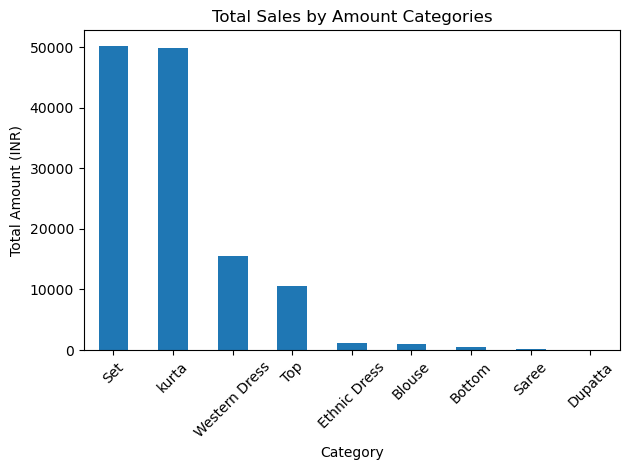

In [89]:
df_cleaned['Category'].value_counts().plot(kind='bar')
plt.title('Total Sales by Amount Categories')
plt.xlabel('Category')
plt.ylabel('Total Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [90]:
df_cleaned['Category'].value_counts()

Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

Text(0.5, 1.0, 'Status of order')

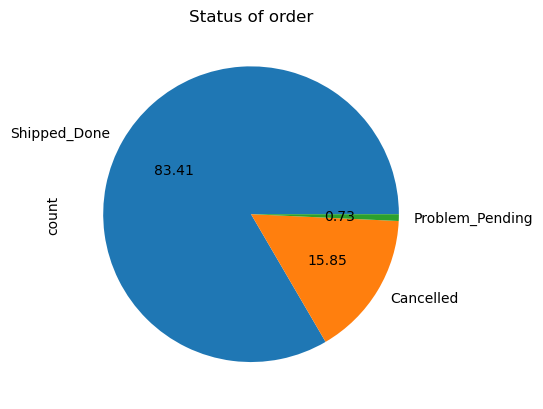

In [93]:
df_cleaned['Status_Group'].value_counts().plot(kind='pie',autopct='%.2f')
plt.title('Status of order')

Text(0.5, 1.0, ' order by states')

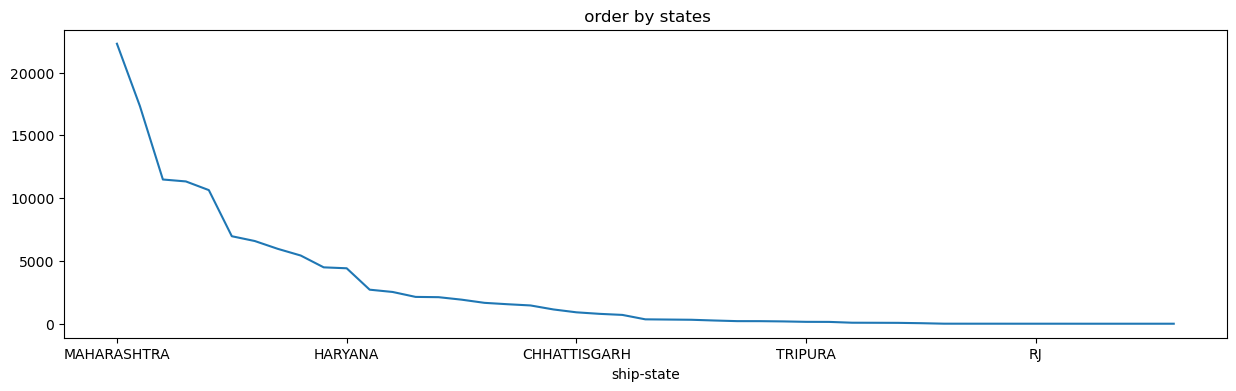

In [95]:
df_cleaned['ship-state'].value_counts().plot(kind='line' ,figsize=(15, 4))
plt.title(' order by states')

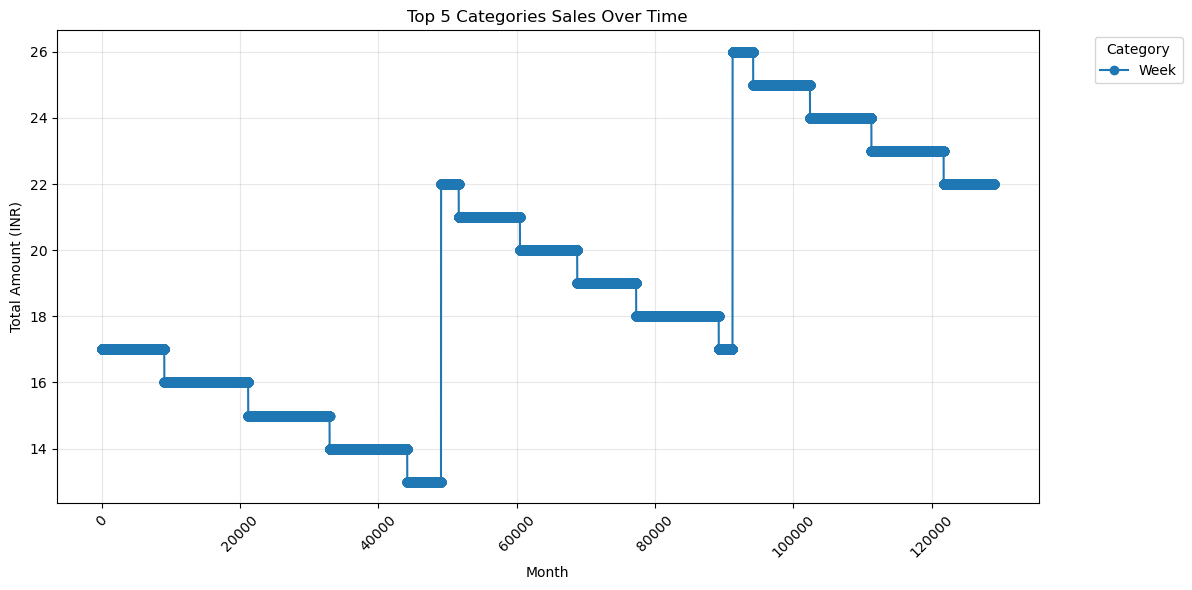

In [97]:
import matplotlib.pyplot as plt
df_cleaned['Week'].plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Top 5 Categories Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Amount (INR)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Top 5 Cities by Total Sales Amount:
 ship-city
BENGALURU    7645114.0
HYDERABAD    5943204.0
MUMBAI       4493313.0
NEW DELHI    4201167.0
CHENNAI      3799098.0
Name: Amount, dtype: float64

Top 5 Zip Codes by Total Sales Amount:
 ship-postal-code
100000.0    77110032.0
201301.0      678058.0
122001.0      479111.0
560068.0      408465.0
560037.0      400819.0
Name: Amount, dtype: float64


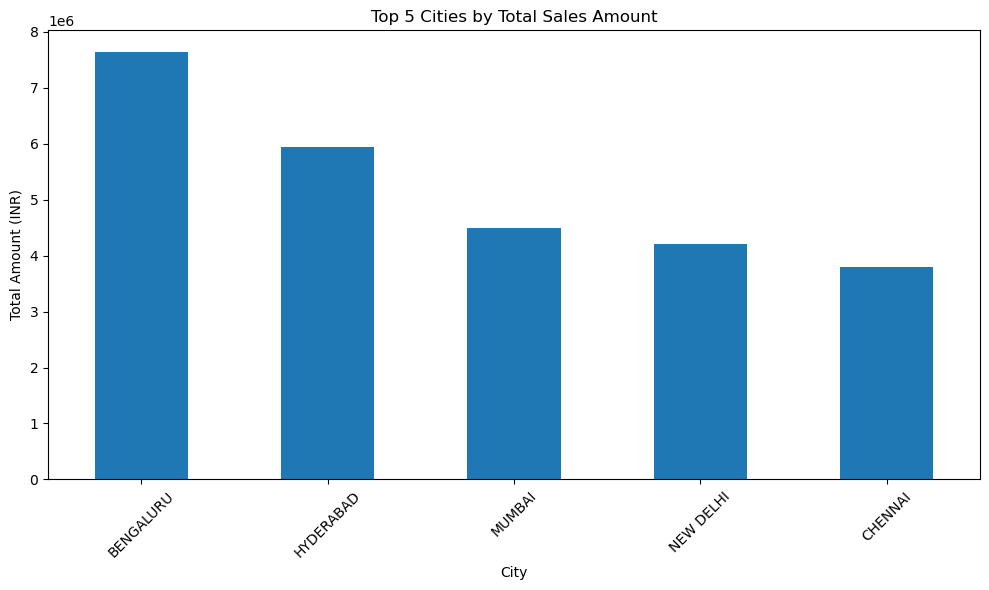

In [98]:
# Top 5 cities by total Amount
top_cities = df_cleaned.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(5)
print("Top 5 Cities by Total Sales Amount:\n", top_cities.round(0))

# Top 5 postal codes by total Amount 
top_zips = df.groupby('ship-postal-code')['Amount'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Zip Codes by Total Sales Amount:\n", top_zips.round(0))

# Barchart for cities
top_cities.plot(kind='bar', figsize=(10, 6))
plt.title('Top 5 Cities by Total Sales Amount')
plt.xlabel('City')
plt.ylabel('Total Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Axes: xlabel='Size', ylabel='count'>

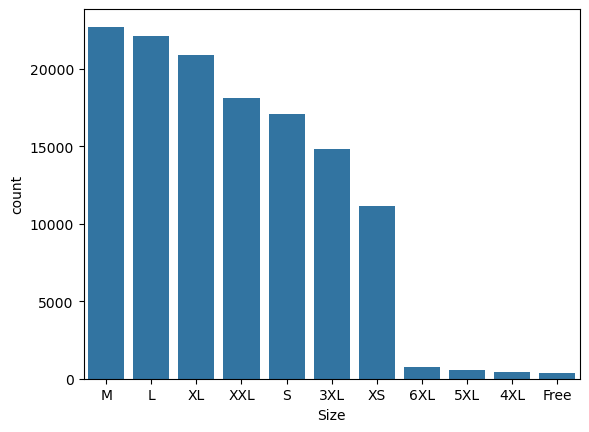

In [101]:
sns.barplot(df_cleaned['Size'].value_counts())

## Which Categories Cancel Most

In [104]:
cancel_by_category = df_cleaned[df_cleaned['Status_Group']=='Cancelled']['Category'].value_counts()
print(cancel_by_category.head(10))


Category
Set              8184
kurta            8009
Western Dress    2467
Top              1410
Ethnic Dress      161
Blouse            128
Bottom             66
Saree              22
Name: count, dtype: int64


<Axes: title={'center': 'Top Cancelled Categories'}, xlabel='Category'>

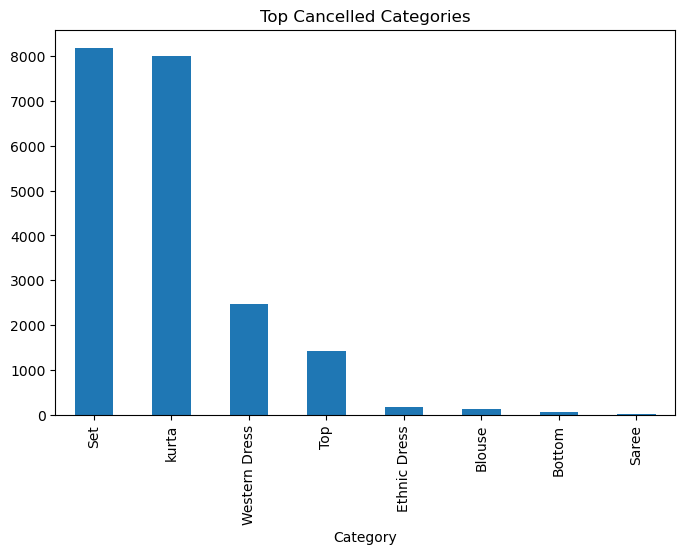

In [106]:
cancel_by_category.head(10).plot(kind='bar', figsize=(8,5), title="Top Cancelled Categories")


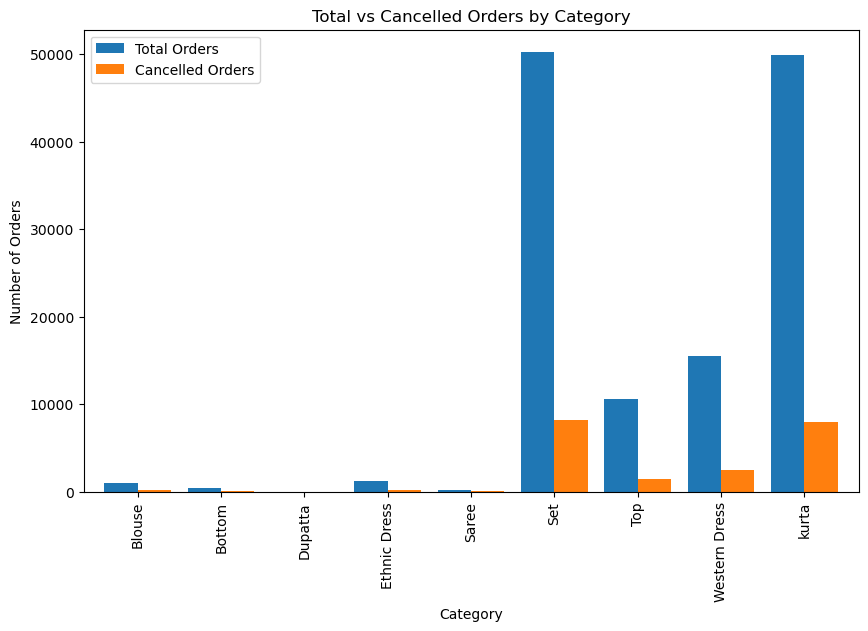

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# Example: group by Category
total_orders = df.groupby('Category').size()
cancel_orders = df[df['Status_Group']=='Cancelled'].groupby('Category').size()

# Combine into one DataFrame
compare_df = pd.DataFrame({
    'Total Orders': total_orders,
    'Cancelled Orders': cancel_orders
}).fillna(0).astype(int)

# Plot side-by-side bars
compare_df[['Total Orders','Cancelled Orders']].plot(
    kind='bar',
    figsize=(10,6),
    width=0.8
)

plt.title("Total vs Cancelled Orders by Category")
plt.ylabel("Number of Orders")
plt.xlabel("Category")
plt.legend()
plt.show()


In [110]:
problem_rate_by_state = (
    df[df['Status_Group']=='Problem_Pending']
    .groupby('ship-state')
    .size()
    .sort_values(ascending=False)
)
print(problem_rate_by_state.head(10))


ship-state
MAHARASHTRA       169
KARNATAKA         126
TELANGANA          82
TAMIL NADU         78
UTTAR PRADESH      74
DELHI              45
WEST BENGAL        43
KERALA             41
ANDHRA PRADESH     41
GUJARAT            38
dtype: int64


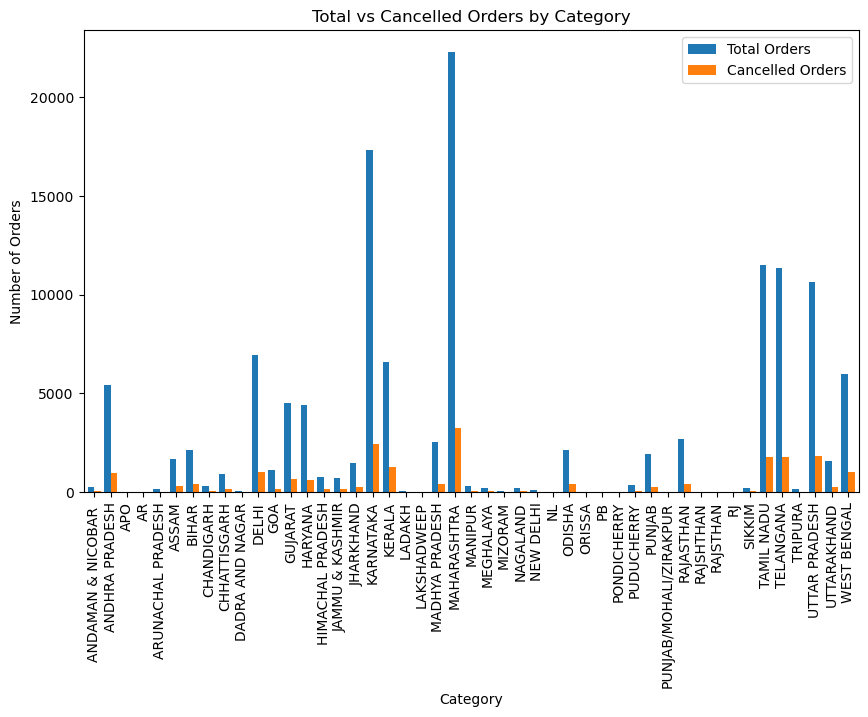

In [112]:
import matplotlib.pyplot as plt
import pandas as pd

# Example: group by Category
total_orders = df.groupby('ship-state').size()
cancel_orders = df[df['Status_Group']=='Cancelled'].groupby('ship-state').size()

# Combine into one DataFrame
compare_df = pd.DataFrame({
    'Total Orders': total_orders,
    'Cancelled Orders': cancel_orders
}).fillna(0).astype(int)

# Plot side-by-side bars
compare_df[['Total Orders','Cancelled Orders']].plot(
    kind='bar',
    figsize=(10,6),
    width=0.8
)

plt.title("Total vs Cancelled Orders by Category")
plt.ylabel("Number of Orders")
plt.xlabel("Category")
plt.legend()
plt.show()


In [113]:
cancel_rate_b2b = (
    df[df['Status_Group']=='Cancelled']
    .groupby('B2B')
    .size()
    / df.groupby('B2B').size()
)
print(cancel_rate_b2b)


B2B
False    0.158972
True     0.094145
dtype: float64


<Axes: title={'center': 'Cancellation Rate: B2B vs Non-B2B'}, xlabel='B2B'>

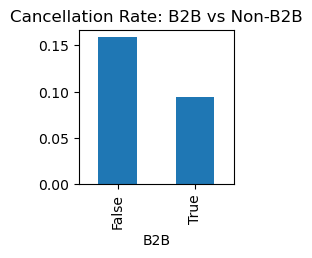

In [114]:
cancel_rate_b2b.plot(kind='bar', figsize=(2,2), title="Cancellation Rate: B2B vs Non-B2B")

# Encoding

In [119]:
df_cleaned.head()

,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B,fulfilled-by,Unnamed: 22,Week,Status_Group,Style_Group
0,Merchant,Amazon.in,Standard,Set,S,Shipped,0,647.62,MUMBAI,MAHARASHTRA,100000.0,False,Easy Ship,True,17,Cancelled,Other
1,Merchant,Amazon.in,Standard,kurta,3XL,Shipped,1,406.00,BENGALURU,KARNATAKA,100000.0,False,Easy Ship,True,17,Shipped_Done,Other
2,Amazon,Amazon.in,Expedited,kurta,XL,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,100000.0,True,Unknown,True,17,Shipped_Done,Other
3,Merchant,Amazon.in,Standard,Western Dress,L,Shipped,0,753.33,PUDUCHERRY,PUDUCHERRY,100000.0,False,Easy Ship,True,17,Cancelled,J0341
4,Amazon,Amazon.in,Expedited,Top,3XL,Shipped,1,574.00,CHENNAI,TAMIL NADU,100000.0,False,Unknown,True,17,Shipped_Done,Other


In [121]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Fulfilment          128975 non-null  object 
 1   Sales Channel       128975 non-null  object 
 2   ship-service-level  128975 non-null  object 
 3   Category            128975 non-null  object 
 4   Size                128975 non-null  object 
 5   Courier Status      128975 non-null  object 
 6   Qty                 128975 non-null  int64  
 7   Amount              128975 non-null  float64
 8   ship-city           128975 non-null  object 
 9   ship-state          128975 non-null  object 
 10  ship-postal-code    128975 non-null  float64
 11  B2B                 128975 non-null  bool   
 12  fulfilled-by        128975 non-null  object 
 13  Unnamed: 22         128975 non-null  bool   
 14  Week                128975 non-null  UInt32 
 15  Status_Group        128975 non-nul

In [123]:
B2B_map = { False : 0 , True : 1 }
df_cleaned['B2B']=df['B2B'].map(B2B_map)

In [125]:
for coloum in df_cleaned.select_dtypes('object'):
    print(coloum)

Fulfilment
Sales Channel 
ship-service-level
Category
Size
Courier Status
ship-city
ship-state
fulfilled-by
Status_Group
Style_Group


In [127]:
from sklearn.preprocessing import LabelEncoder
lab_en = LabelEncoder()
for coloum in df_cleaned.select_dtypes('object'):
    df_cleaned[coloum] = lab_en.fit_transform(df_cleaned[coloum])
    

In [128]:
df_cleaned

,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B,fulfilled-by,Unnamed: 22,Week,Status_Group,Style_Group
0,1,0,1,5,7,1,0,647.62,4331,22,100000.0,0,0,True,17,0,15
1,1,0,1,8,0,1,1,406.00,810,17,100000.0,0,0,True,17,2,15
2,0,0,0,8,8,1,1,329.00,4665,22,100000.0,1,1,True,17,2,15
3,1,0,1,7,5,1,0,753.33,5457,33,100000.0,0,0,True,17,0,4
4,0,0,0,6,0,1,1,574.00,1314,41,100000.0,0,1,True,17,2,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,0,0,0,8,8,1,1,517.00,2540,42,100000.0,0,1,False,22,2,15
128971,0,0,0,5,6,1,1,999.00,2337,13,100000.0,0,1,False,22,2,15
128972,0,0,0,7,10,1,1,690.00,2540,42,500049.0,0,1,False,22,2,15
128973,0,0,0,5,9,1,1,1199.00,2388,12,100000.0,0,1,False,22,2,15


In [129]:
df['Unnamed: 22'].value_counts()

Unnamed: 22
False    79925
True     49050
Name: count, dtype: int64

# Coreltion heatmap

<Axes: >

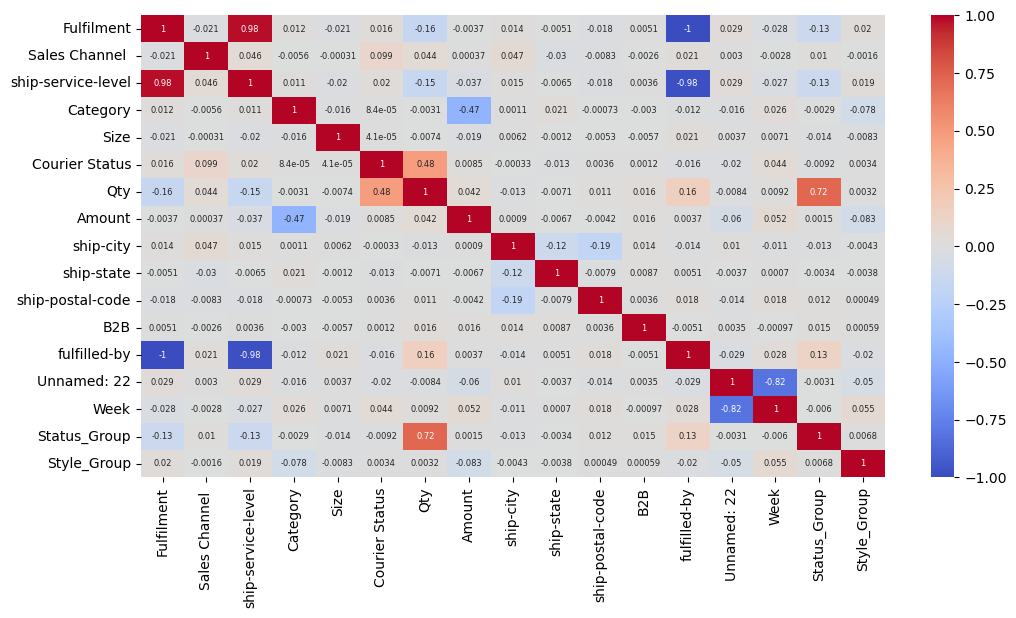

In [135]:
import seaborn as sns
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size' : 6},
    cmap = 'coolwarm'
)

In [137]:
df['fulfilled-by'].value_counts()

fulfilled-by
Unknown      89698
Easy Ship    39277
Name: count, dtype: int64

In [139]:
df['Fulfilment'].value_counts()

Fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64

In [141]:
df['ship-service-level'].value_counts()

ship-service-level
Expedited    88615
Standard     40360
Name: count, dtype: int64

In [143]:
# df_cleaned[] = df_cleaned['Amount']/df_cleaned['Qty']

In [145]:
 # df_cleaned['rupi_per_pod'].value_counts()

In [147]:
df_cleaned.describe()

,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,B2B,fulfilled-by,Week,Status_Group,Style_Group
count,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.000000,128975.0,128975.000000,128975.000000
mean,0.304532,0.000961,0.312929,6.414010,6.359574,1.005784,0.904431,648.718085,3341.631440,25.311836,127229.885683,0.006753,0.695468,19.068657,1.675588,13.902097
std,0.460211,0.030992,0.463687,1.521719,2.862824,0.312705,0.313354,276.089292,2016.080177,13.710483,102125.846586,0.081901,0.460211,3.706868,0.732286,3.429463
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000,0.000000,0.000000,13.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,5.000000,5.000000,1.000000,1.000000,455.927108,1431.500000,17.000000,100000.000000,0.000000,0.000000,16.0,2.000000,15.000000
50%,0.000000,0.000000,0.000000,7.000000,7.000000,1.000000,1.000000,612.000000,3066.000000,22.000000,100000.000000,0.000000,1.000000,19.0,2.000000,15.000000
75%,1.000000,0.000000,1.000000,8.000000,8.000000,1.000000,1.000000,788.000000,4798.000000,41.000000,100000.000000,0.000000,1.000000,22.0,2.000000,15.000000
max,1.000000,1.000000,1.000000,8.000000,10.000000,2.000000,15.000000,5584.000000,7296.000000,46.000000,560102.000000,1.000000,1.000000,26.0,2.000000,20.000000


In [ ]:
#X = X.drop("Courier Status", axis=1)

In [236]:
x = df_cleaned.drop('Status_Group',axis=1)
y = df_cleaned['Status_Group']

# Courier Status was highly correlated with the target variable and introduced target leakage.
x = x.drop("Courier Status", axis=1)

In [238]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train, y_test = train_test_split(
    x,y,test_size= 0.2,
    random_state=42)

# StandardScaler

In [241]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [242]:
X_scaler.shape

(103180, 15)

# LogisticRegression model

In [246]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score ,recall_score,precision_score,f1_score
from sklearn.model_selection import cross_val_score

lg =LogisticRegression(max_iter=1800, tol=1e-4, solver='lbfgs')
lg.fit(X_scaler,y_train)
y_read = lg.predict(X_test_sc)
y_pred = lg.predict(X_scaler)

# print('precision test data: - ',precision_score(y_read,y_test)*100,'%')
print('accuracy test data: - ',accuracy_score(y_read,y_test)*100,'%')
print('accuracy train data: - ',accuracy_score(y_pred,y_train)*100,"%")
# results clearly overfitting dikhate hain.


accuracy test data: -  93.34754797441364 %
accuracy train data: -  93.40279123861214 %


# DecisionTreeClassifier model

In [248]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, min_samples_split=16, random_state=42)
dt.fit(X_train,y_train)
y_read = dt.predict(X_test)
y_pred = dt.predict(X_train)

print('accuracy test data: - ',accuracy_score(y_read,y_test)*100,'%')
print('accuracy train data: - ',accuracy_score(y_pred,y_train)*100,"%")
#print('precision test data: - ',precision_score(y_read,y_test)*100,'%')

accuracy test data: -  93.33204109323512 %
accuracy train data: -  93.40763713898042 %


# XGBoot classification model

In [265]:
import xgboost as xgb
xgbcl = xgb.XGBClassifier(
    n_estimators = 100,
    max_depth = 3,
    learning_rate = 0.1,
    eval_metric='logloss',
    random_state=42
)

In [269]:
xgbcl.fit(X_train,y_train)
y_read = xgbcl.predict(X_test)
y_pred = xgbcl.predict(X_train)

print('accuracy test data: - ',accuracy_score(y_read,y_test)*100,'%')
print('accuracy train data: - ',accuracy_score(y_pred,y_train)*100,"%")

accuracy test data: -  93.33979453382439 %
accuracy train data: -  93.40763713898042 %


In [271]:
from sklearn.metrics import confusion_matrix ,classification_report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_read))

Confusion Matrix:
 [[ 2514     0  1551]
 [    1   111    84]
 [   25    57 21452]]


In [273]:
print("Classification Report:\n", classification_report(y_test, y_read))

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.62      0.76      4065
           1       0.66      0.57      0.61       196
           2       0.93      1.00      0.96     21534

    accuracy                           0.93     25795
   macro avg       0.86      0.73      0.78     25795
weighted avg       0.94      0.93      0.93     25795



In [275]:
from sklearn.metrics import accuracy_score ,recall_score,precision_score,f1_score
#print('precision test data: - ',precision_score(y_read,y_test)*100,'%')

print("Precision (macro):", precision_score(y_test, y_read, average='macro'))
print("Recall (micro):", recall_score(y_test, y_read, average='micro'))
print("F1 (weighted):", f1_score(y_test, y_read, average='weighted'))

Precision (macro): 0.8598863298571846
Recall (micro): 0.9333979453382438
F1 (weighted): 0.927286859199545
